# VHH HEFT predictions

Closed-form **$W^\pm HH$** and **$ZHH$** at LO / NNLO. Run from the **repo root**.

| § | What |
|---|------|
| 1 | Configuration |
| 2 | Spot check at one $\kappa$ |
| 3 | `scan_and_save()` → `Results/Points/` |
| 4–5 | Plots (optional) |
| 6 | Wilson tables |


## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vhh_predict import (
    CHANNELS,
    TABLE_ENERGIES_TEV,
    build_channel_tables,
    format_prediction,
    latex_wilson_tables_for_process,
    load_analysis,
    plots_dir,
    resolve_scan_axis,
    scan_and_save,
    scan_axes,
    tables_dir,
)
from vhh_predict.plots import (
    X_LABELS,
    plot_enhancement_only,
    plot_kfactor_only,
    plot_sigma_lo_only,
    plot_sigma_nnlo_and_enhancement_nnlo,
    plot_sigma_nnlo_and_kfactor,
    plot_sigma_only,
)
from vhh_predict.tables import KAPPA_PLAIN, ZHH_TABLE_GROUPS

PLOTS_DIR = plots_dir()
TABLES_DIR = tables_dir()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Configuration

| Variable | Meaning |
|----------|---------|
| `PROCESS` | `WplusHH`, `WminusHH`, `ZHH` |
| `ENERGY_TEV` | `13.6` or `14.0` |
| `KAPPA` | W$\pm$: `(κ_λ, κ_W, κ_{2W})` — ZHH: `(κ_λ, κ_Z, κ_{2Z}, κ_t)` |
| `COMPARE_SIMULATION` | Compare to MadGraph in §2 spot check only |
| `SAVE_SCAN_POINTS` | Write scan JSON to `Results/Points/` (§3) |
| `SAVE_PLOTS` | Write PNGs to `Results/Plots/` (§4–5) |
| `SIGMA_INSET` | Zoom inset on σ_NNLO panels |


In [2]:
PROCESS = "ZHH"
ENERGY_TEV = 14.0
KAPPA = (3.0, 1.0, 1.0, 1.0)  # ZHH: include κ_t

COMPARE_SIMULATION = True
UNCERTAINTIES_AS_PERCENT = True
SAVE_SCAN_POINTS = True
SAVE_PLOTS = True
SIGMA_INSET = True

analysis = load_analysis(PROCESS, ENERGY_TEV)
nn_label = analysis.nnlo_label
FIXED_KAPPA = KAPPA

print(f"{PROCESS} @ {ENERGY_TEV} TeV  |  scan axes: {', '.join(scan_axes(PROCESS))}")


ZHH @ 14.0 TeV  |  scan axes: kappa_lambda, kappa_z, kappa_2z, kappa_t


## 2. Spot check

In [3]:
prediction = format_prediction(
    analysis, KAPPA,
    as_percent=UNCERTAINTIES_AS_PERCENT,
    compare_simulation=COMPARE_SIMULATION,
)
print(prediction)


ZHH @ 14.0 TeV  κ=(3, 1, 1, 1)
  σ_LO   HEFT 0.734171  +0.81%/-1.07% (scale)  ±2.01% (PDF+αs)    sim 0.740306  (diff -0.829%)
  σ_NNLO  HEFT 0.944590  +2.03%/-1.65% (scale)  ±1.95% (PDF+αs)    sim 0.948605  (diff -0.423%)
  σ_HEFT/σ_SM (LO)   HEFT 2.403167
  σ_HEFT/σ_SM (NNLO)  HEFT 2.263396
  K      HEFT 1.286607    sim 1.28137  (diff +0.409%)


## 3. Scan (and optionally save)

One `scan_and_save()` call — results in `scan_data` for §4–5. Set `SAVE_SCAN_POINTS=True` to also write `Results/Points/{Process}_{energy}TeV_{axis}.txt` (comment header + tab-separated table; uncertainty bands stay in memory for plots).


In [4]:
scan_axis = "kappa_t"
scan_vmin, scan_vmax = 0.85, 1.15
scan_n_points = 400

scan_data, scan_points_file = scan_and_save(
    analysis,
    scan_axis,
    vmin=scan_vmin,
    vmax=scan_vmax,
    fixed_kappa=FIXED_KAPPA,
    n_points=scan_n_points,
    uncertainties=True,
    save=SAVE_SCAN_POINTS,
)
if SAVE_SCAN_POINTS:
    print(f"Saved {scan_points_file}")


Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/Results/Points/ZHH_14TeV_kappa_t.txt


## 4. Single-panel plots

Uses `scan_data` from §3. Run §3 first.

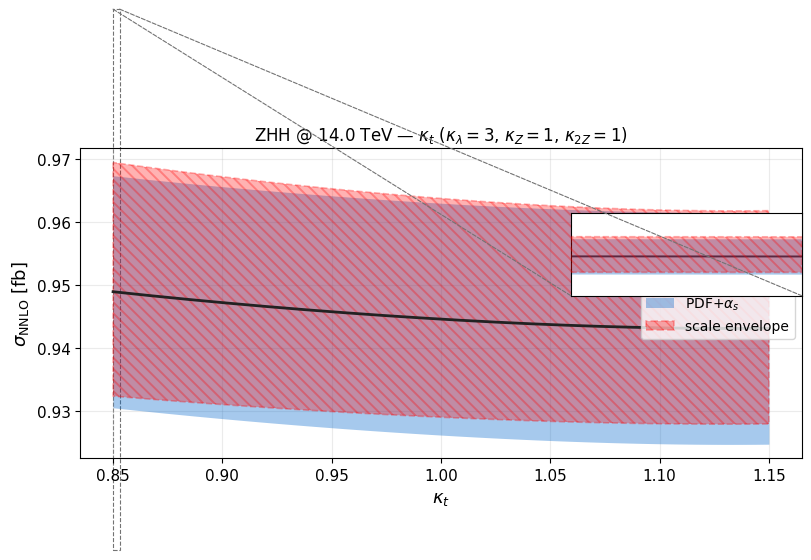

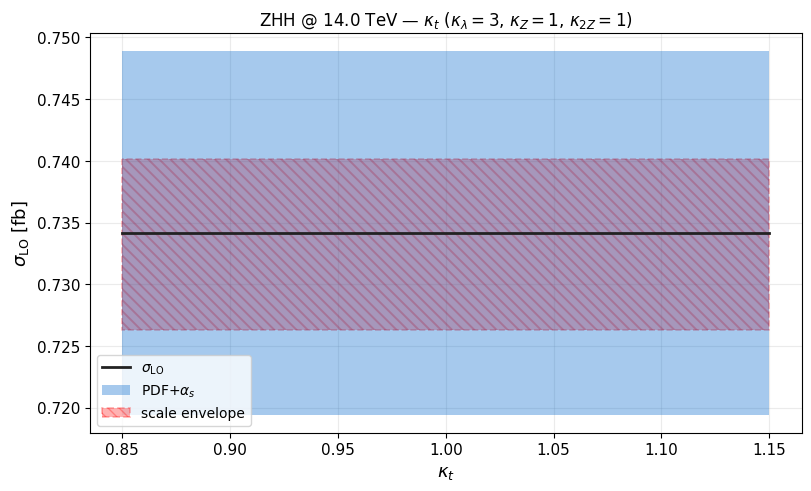

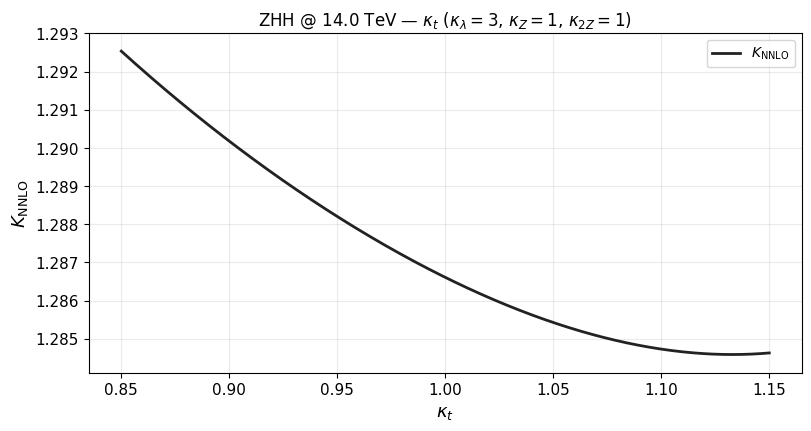

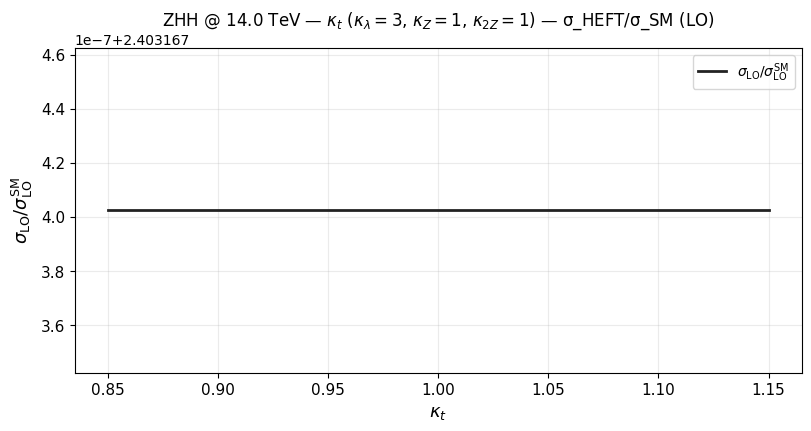

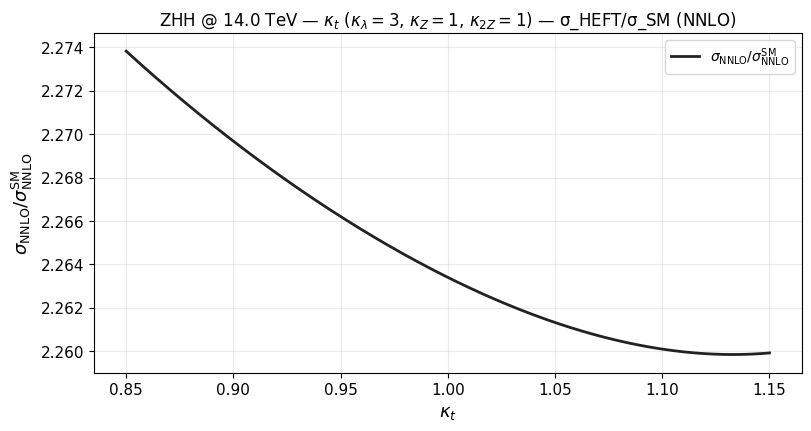

In [5]:
scan_idx, scan_x_key = resolve_scan_axis(PROCESS, scan_axis)
scan_axis_label = X_LABELS[scan_x_key]
kappa_names = [r"\lambda", "Z", r"2Z", "t"] if PROCESS == "ZHH" else [r"\lambda", "W", r"2W"]
n_kappa = 4 if PROCESS == "ZHH" else 3
fixed_title = ", ".join(
    rf"$\kappa_{{{kappa_names[i]}}}={FIXED_KAPPA[i]:g}$"
    for i in range(n_kappa) if i != scan_idx
)
scan_title_base = f"{PROCESS} @ {ENERGY_TEV} TeV — {scan_axis_label} ({fixed_title})"
prefix = f"{PROCESS}_{ENERGY_TEV}TeV_{scan_x_key}"

plot_sigma_only(scan_data, title=scan_title_base, nnlo_label=nn_label,
    sigma_inset=SIGMA_INSET,
    output=PLOTS_DIR / f"{prefix}_sigma_nnlo.png", save=SAVE_PLOTS)
plt.show()

plot_sigma_lo_only(scan_data, title=scan_title_base,
    output=PLOTS_DIR / f"{prefix}_sigma_lo.png", save=SAVE_PLOTS)
plt.show()

plot_kfactor_only(scan_data, title=scan_title_base, nnlo_label=nn_label,
    output=PLOTS_DIR / f"{prefix}_K.png", save=SAVE_PLOTS)
plt.show()

for order, tag in (("LO", "sigmaSM_LO"), (nn_label, f"sigmaSM_{nn_label}")):
    plot_enhancement_only(scan_data, order=order, show_uncertainty=False,
        title=f"{scan_title_base} — σ_HEFT/σ_SM ({order})", nnlo_label=nn_label,
        output=PLOTS_DIR / f"{prefix}_{tag}.png", save=SAVE_PLOTS)
    plt.show()


## 5. Two-panel plots

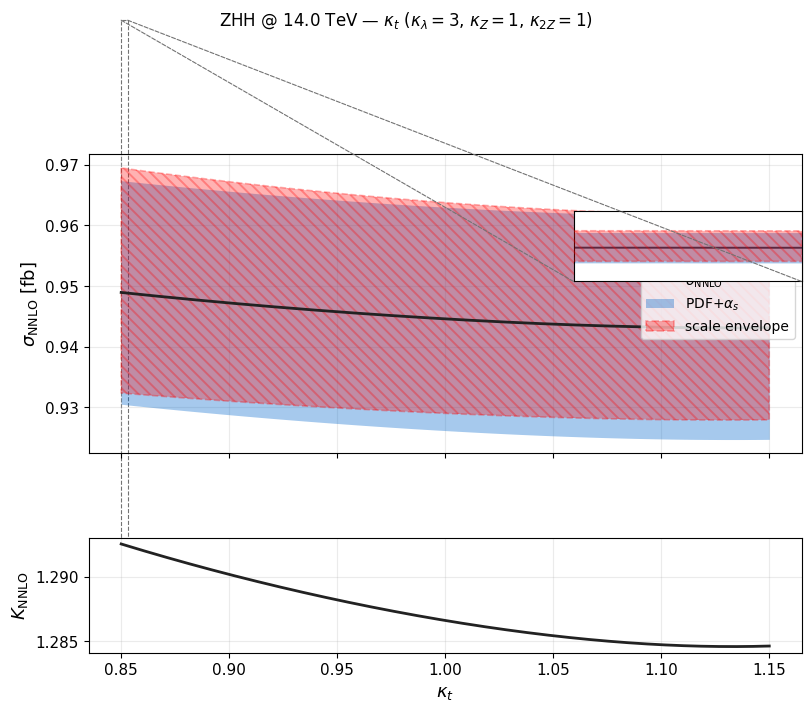

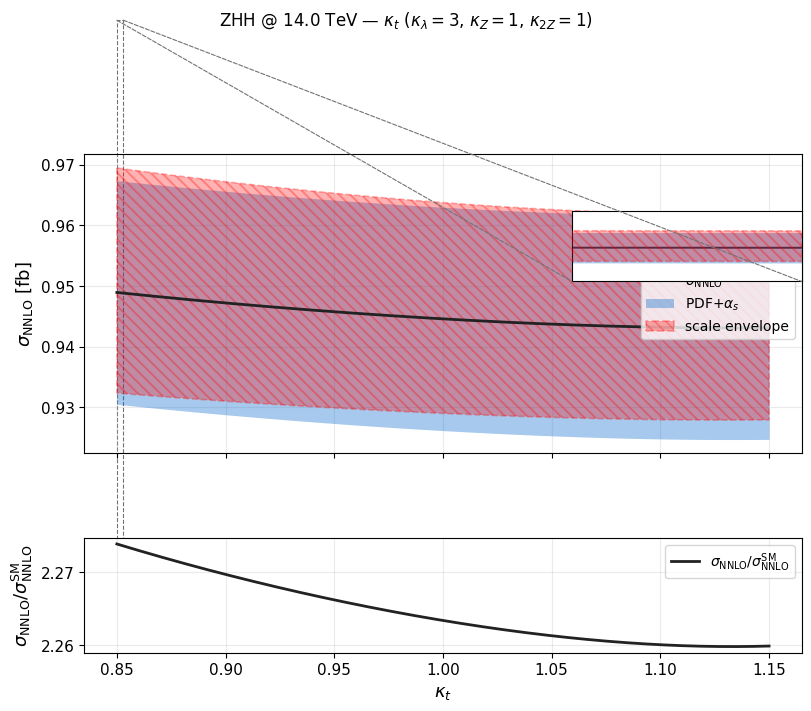

In [6]:
plot_sigma_nnlo_and_kfactor(scan_data, title=scan_title_base, nnlo_label=nn_label,
    sigma_inset=SIGMA_INSET,
    output=PLOTS_DIR / f"{prefix}_sigma_nnlo_K.png", save=SAVE_PLOTS)
plt.show()

plot_sigma_nnlo_and_enhancement_nnlo(scan_data, title=scan_title_base, nnlo_label=nn_label,
    sigma_inset=SIGMA_INSET, show_enhancement_uncertainty=False,
    output=PLOTS_DIR / f"{prefix}_sigma_nnlo_sigmaSM_{nn_label}.png", save=SAVE_PLOTS)
plt.show()


## 6. Kappa tables

In [7]:
latex_path = TABLES_DIR / "Kappa_tables.tex"
latex_blocks = []
for process in CHANNELS:
    display(Markdown(f"## {process}"))
    tables = build_channel_tables(process, energies_tev=TABLE_ENERGIES_TEV)
    if process == "ZHH":
        for axes in ZHH_TABLE_GROUPS:
            key = "_".join(axes)
            display(Markdown(f"### {', '.join(KAPPA_PLAIN[a] for a in axes)}"))
            display(tables[key])
    else:
        display(tables)
    tex = latex_wilson_tables_for_process(process, energies_tev=TABLE_ENERGIES_TEV)
    latex_blocks.append(tex)
    display(Markdown("**LaTeX**"))
    print(tex)
latex_path.write_text("\n\n".join(latex_blocks), encoding="utf-8")
print(f"Saved {latex_path}")


## WplusHH

,sqrt s [TeV],SM,κ_λ=-1.7,κ_λ=6.6,κ_W=0.9,κ_W=1.2,κ_2W=0.4,κ_2W=1.6
0,13.6,0.358 +0.36%/-0.40% ±2.3%,0.128 +0.28%/-0.45% ±2.6%,2.653 +0.40%/-0.41% ±2.2%,0.324 +0.35%/-0.40% ±2.3%,0.464 +0.36%/-0.40% ±2.3%,0.175 +0.35%/-0.41% ±2.3%,0.685 +0.33%/-0.41% ±2.3%
1,14.0,0.374 +0.37%/-0.40% ±2.2%,0.135 +0.28%/-0.44% ±2.6%,2.771 +0.41%/-0.40% ±2.2%,0.339 +0.36%/-0.40% ±2.2%,0.485 +0.37%/-0.40% ±2.2%,0.183 +0.36%/-0.40% ±2.3%,0.717 +0.34%/-0.40% ±2.3%


**LaTeX**

\begin{table}[htbp]
\centering
\resizebox{\textwidth}{!}{%
  \renewcommand{\arraystretch}{1.45}%
  \setlength{\tabcolsep}{7pt}%
  \begin{tabular}{c | @{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c}
    \hline
    \multirow{2}{*}{$\sqrt{s}$} & \multicolumn{7}{c}{$\sigma$} \\
    \cline{2-8}
     & SM & $\kappa_\lambda=-1.7$ & $\kappa_\lambda=6.6$ & $\kappa_W=0.9$ & $\kappa_W=1.2$ & $\kappa_{2W}=0.4$ & $\kappa_{2W}=1.6$ \\
    \hline
    $13.6$ & $0.358_{+0.36\%}^{-0.40\%} \pm 2.3\%$ & $0.128_{+0.28\%}^{-0.45\%} \pm 2.6\%$ & $2.653_{+0.40\%}^{-0.41\%} \pm 2.2\%$ & $0.324_{+0.35\%}^{-0.40\%} \pm 2.3\%$ & $0.464_{+0.36\%}^{-0.40\%} \pm 2.3\%$ & $0.175_{+0.35\%}^{-0.41\%} \pm 2.3\%$ & $0.685_{+0.33\%}^{-0.41\%} \pm 2.3\%$ \\
    $14$ & $0.374_{+0.37\%}^{-0.40\%} \pm 2.2\%$ & $0.135_{+0.28\%}^{-0.44\%} \pm 2.6\%$ & $2.771_{+0.41\%}^{-0.40\%} \pm 2.2\%$ & $0.339_{+0.36\%}^{-0.40\%} \pm 2.2\%$ & $0.485_{+0.37\%}^{-0.40\%}

## WminusHH

...

,sqrt s [TeV],SM,κ_λ=-1.7,κ_λ=6.6,κ_t=0.9,κ_t=1.2
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.166 +8.36%/-6.41% ±1.9%,2.516 +1.47%/-1.24% ±2.0%,0.393 +3.22%/-2.54% ±1.9%,0.406 +3.97%/-3.09% ±1.9%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.176 +8.38%/-6.43% ±1.8%,2.642 +1.48%/-1.25% ±2.0%,0.414 +3.25%/-2.56% ±1.9%,0.428 +4.02%/-3.12% ±1.9%


### κ_Z, κ_2Z

,sqrt s [TeV],SM,κ_Z=0.9,κ_Z=1.2,κ_2Z=0.4,κ_2Z=1.6
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.344 +2.83%/-2.25% ±2.0%,0.548 +4.44%/-3.44% ±1.9%,0.221 +5.99%/-4.59% ±1.8%,0.690 +2.01%/-1.66% ±2.1%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.362 +2.86%/-2.27% ±1.9%,0.577 +4.49%/-3.47% ±1.8%,0.234 +6.05%/-4.64% ±1.8%,0.726 +2.03%/-1.67% ±2.0%


**LaTeX**

\begin{table}[htbp]
\centering
\resizebox{\textwidth}{!}{%
  \renewcommand{\arraystretch}{1.45}%
  \setlength{\tabcolsep}{7pt}%
  \begin{tabular}{l@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c@{\hspace{10pt}}c}
    \hline
    \multirow{2}{*}{$\sqrt{s}$ [TeV]} & \multicolumn{5}{c}{$\sigma$ [fb]} \\
    \cline{2-6}
     & SM & $\kappa_\lambda=-1.7$ & $\kappa_\lambda=6.6$ & $\kappa_t=0.9$ & $\kappa_t=1.2$ \\
    \hline
    $13.6$ & $0.396_{+3.39\%}^{-2.66\%} \pm 1.9\%$ & $0.166_{+8.36\%}^{-6.41\%} \pm 1.9\%$ & $2.516_{+1.47\%}^{-1.24\%} \pm 2.0\%$ & $0.393_{+3.22\%}^{-2.54\%} \pm 1.9\%$ & $0.406_{+3.97\%}^{-3.09\%} \pm 1.9\%$ \\
    $14$ & $0.417_{+3.42\%}^{-2.69\%} \pm 1.9\%$ & $0.176_{+8.38\%}^{-6.43\%} \pm 1.8\%$ & $2.642_{+1.48\%}^{-1.25\%} \pm 2.0\%$ & $0.414_{+3.25\%}^{-2.56\%} \pm 1.9\%$ & $0.428_{+4.02\%}^{-3.12\%} \pm 1.9\%$ \\
    \hline
  \end{tabular}%
}%
\caption{Cross-section values $\sigma$ [fb] for $ZHH$ process for $\sqrt{s}=13.6,\, 14$ TeV, with $\